In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches
import matplotlib.ticker as ticker

In [2]:
df=pd.read_table('BOR2_313_leafB.txt',header=None)
df

,0,1,2
0,12768,96.680330,1
1,12909,68.320123,0
2,12910,83.270692,1
3,12915,92.478577,1
4,13181,65.550355,0
...,...,...,...
121,3968_BW,54.849751,0
122,3968_BX,92.021164,1
123,3968_BY,93.641845,1
124,3968_BZ,101.476046,.


In [3]:
df=df.rename(columns={0:"Accession", 1:"B", 2:"Genotype"})
df

,Accession,B,Genotype
0,12768,96.680330,1
1,12909,68.320123,0
2,12910,83.270692,1
3,12915,92.478577,1
4,13181,65.550355,0
...,...,...,...
121,3968_BW,54.849751,0
122,3968_BX,92.021164,1
123,3968_BY,93.641845,1
124,3968_BZ,101.476046,.


Text(0, 0.5, 'Leaf [B] \n(µg/g DW)')

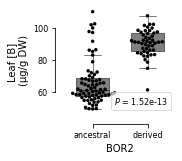

In [4]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})
Order=['0','1']
@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(5*cm,5*cm))
ax=sns.boxplot(x='Genotype', 
            y='B',
            data=df,
            order=Order,
            color='grey',
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
ax=sns.swarmplot(x='Genotype', 
            y='B',
            data=df,
            order=Order,
            color='0',
            s=3.5)
r,p = mannwhitneyu(df[df['Genotype'] == '0'].B,df[df['Genotype'] == '1'].B)
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='best', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
# ax.yaxis.set_major_locator(ticker.MultipleLocator(300))
sns.despine(trim=True,offset=10)
ax.set_xticklabels(['ancestral', 'derived'])
plt.tick_params(labelsize=8)
# plt.xlabel('$\itCNNM1$ L77fs',fontsize=10)
plt.xlabel('BOR2',fontsize=10)
plt.ylabel('Leaf [B] \n(µg/g DW)',fontsize=10)
# plt.savefig("Fig3c.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig3c.svg", format="svg",bbox_inches="tight",facecolor="w")
# plt.savefig("Fig3c.pdf", format="pdf",bbox_inches="tight")